# Y 분포 분석 (whiff%)
- 데이터: `features_pitch15.parquet` (X구간 확정본)
- 목적: whiff% 분포 파악 → Phase 6 이상치 처리 기준 설정

In [11]:
import os, sys

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    if not os.path.exists('/content/drive/MyDrive'):
        from google.colab import drive
        drive.mount('/content/drive')
    DRIVE     = '/content/drive/MyDrive/투수 컨디션 예측 ML'
else:
    DRIVE     = r'c:\Users\suyou\OneDrive\Desktop\ASAC\PROJECT\투수 컨디션 예측'

FEATURE_DIR = os.path.join(DRIVE, '0_data', '4_features')
FEAT_PATH   = os.path.join(FEATURE_DIR, 'features_pitch15.parquet')
IMAGE_DIR   = os.path.join(DRIVE, '5_eda', 'image')   # 항상 Drive or 로컬 동일 경로
os.makedirs(IMAGE_DIR, exist_ok=True)

print(f'환경: {"코랩" if IN_COLAB else "로컬"}')
print(f'데이터: {FEAT_PATH}')
print(f'이미지 저장 경로: {IMAGE_DIR}')

환경: 코랩
데이터: /content/drive/MyDrive/투수 컨디션 예측 ML/0_data/4_features/features_pitch15.parquet
이미지 저장 경로: /content/drive/MyDrive/투수 컨디션 예측 ML/5_eda/image


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet(FEAT_PATH)
y  = df['y_whiff']

print(f'전체 샘플: {len(df):,}행')
print(f'시즌별 샘플:\n{df["season"].value_counts().sort_index()}')

전체 샘플: 23,225행
시즌별 샘플:
season
2021    4596
2022    4664
2023    4611
2024    4668
2025    4686
Name: count, dtype: int64


## 1. 기초 통계

In [13]:
stats = y.describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99])
print(stats.round(4))
print(f'\nNaN 수    : {y.isna().sum()}')
print(f'0.0 경기   : {(y == 0).sum()}  ({(y == 0).mean():.1%})')
print(f'1.0 경기   : {(y == 1).sum()}  ({(y == 1).mean():.1%})')
print(f'< 0.05    : {(y < 0.05).sum()}  ({(y < 0.05).mean():.1%})')
print(f'> 0.60    : {(y > 0.60).sum()}  ({(y > 0.60).mean():.1%})')

count    23225.0000
mean         0.2232
std          0.0901
min          0.0000
1%           0.0385
5%           0.0857
10%          0.1111
25%          0.1591
50%          0.2174
75%          0.2812
90%          0.3421
95%          0.3791
99%          0.4560
max          0.7647
Name: y_whiff, dtype: float64

NaN 수    : 0
0.0 경기   : 101  (0.4%)
1.0 경기   : 0  (0.0%)
< 0.05    : 321  (1.4%)
> 0.60    : 7  (0.0%)


## 2. 전체 분포

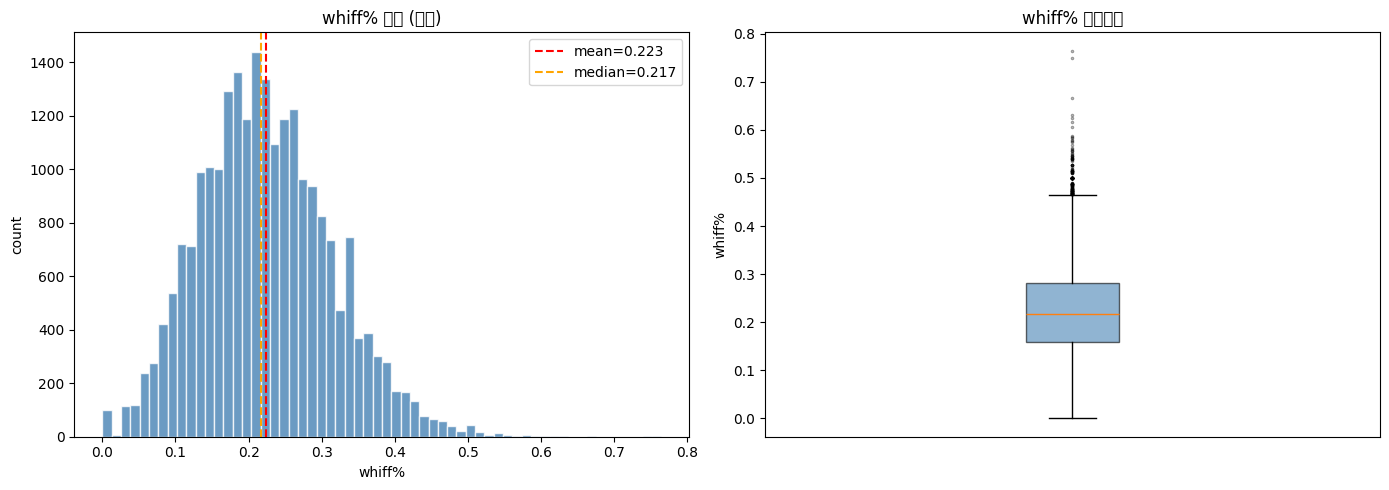

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
ax = axes[0]
ax.hist(y, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(y.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'mean={y.mean():.3f}')
ax.axvline(y.median(), color='orange', linestyle='--', linewidth=1.5, label=f'median={y.median():.3f}')
ax.set_xlabel('whiff%')
ax.set_ylabel('count')
ax.set_title('whiff% 분포 (전체)')
ax.legend()

# 박스플롯
ax = axes[1]
ax.boxplot(y.dropna(), vert=True, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           flierprops=dict(marker='.', markersize=3, alpha=0.4))
ax.set_ylabel('whiff%')
ax.set_title('whiff% 박스플롯')
ax.set_xticks([])

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, '01_overall_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. 시즌별 분포

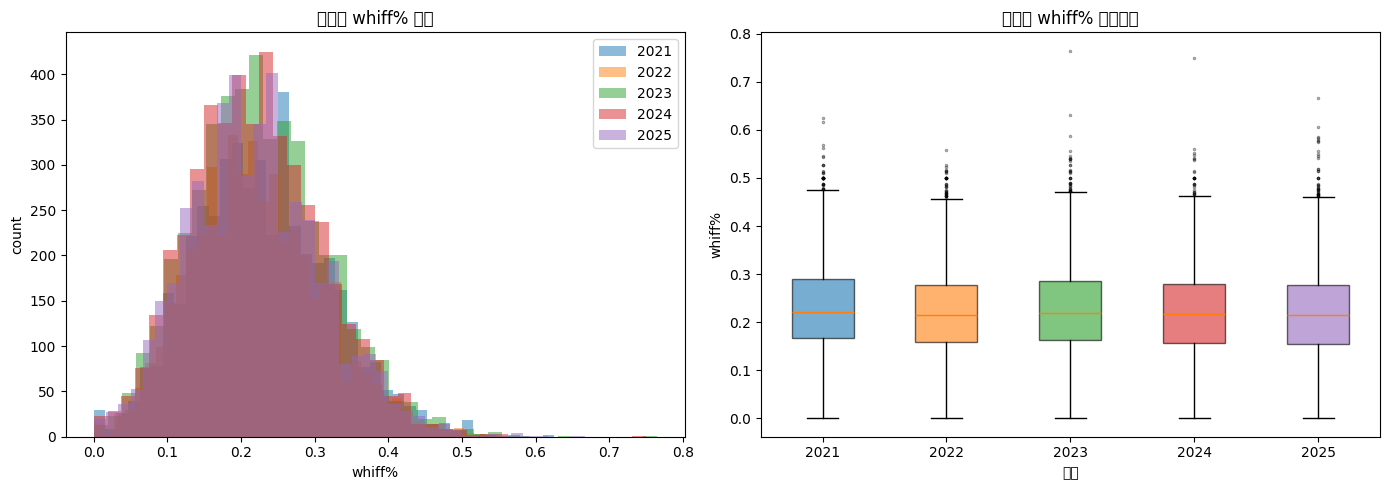


시즌별 요약:
          mean     std  min     25%     50%     75%     max
season                                                     
2021    0.2290  0.0929  0.0  0.1667  0.2222  0.2903  0.6250
2022    0.2216  0.0878  0.0  0.1579  0.2143  0.2778  0.5588
2023    0.2256  0.0906  0.0  0.1622  0.2195  0.2857  0.7647
2024    0.2204  0.0888  0.0  0.1562  0.2162  0.2791  0.7500
2025    0.2196  0.0900  0.0  0.1538  0.2143  0.2766  0.6667


In [15]:
seasons = sorted(df['season'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 시즌별 히스토그램 오버레이
ax = axes[0]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for season, color in zip(seasons, colors):
    sub = df[df['season'] == season]['y_whiff']
    ax.hist(sub, bins=40, alpha=0.5, label=str(season), color=color)
ax.set_xlabel('whiff%')
ax.set_ylabel('count')
ax.set_title('시즌별 whiff% 분포')
ax.legend()

# 시즌별 박스플롯
ax = axes[1]
data_by_season = [df[df['season'] == s]['y_whiff'].dropna().values for s in seasons]
bp = ax.boxplot(data_by_season, labels=seasons, patch_artist=True,
                flierprops=dict(marker='.', markersize=3, alpha=0.4))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_xlabel('시즌')
ax.set_ylabel('whiff%')
ax.set_title('시즌별 whiff% 박스플롯')

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, '02_season_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# 수치 요약
print('\n시즌별 요약:')
print(df.groupby('season')['y_whiff'].describe()[['mean','std','min','25%','50%','75%','max']].round(4))

## 4. 이상치 분석
Phase 6에서 어떤 기준으로 clip/제거할지 결정하기 위한 분석

In [16]:
# IQR 기반 이상치
q1, q3 = y.quantile(0.25), y.quantile(0.75)
iqr = q3 - q1
lower_iqr = q1 - 1.5 * iqr
upper_iqr = q3 + 1.5 * iqr

outlier_iqr = df[(y < lower_iqr) | (y > upper_iqr)]

print(f'IQR 기반 이상치 범위: [{lower_iqr:.4f}, {upper_iqr:.4f}]')
print(f'IQR 이상치 수: {len(outlier_iqr)}개 ({len(outlier_iqr)/len(df):.1%})')
print()

# 백분위 기반 후보 기준들
candidates = [0.01, 0.02, 0.05, 0.95, 0.98, 0.99]
print('백분위별 whiff% 값:')
for p in candidates:
    print(f'  {p:.0%} : {y.quantile(p):.4f}')
print()

# 극단값 샘플 확인
print('하위 5개 (whiff% 가장 낮음):')
print(df.nsmallest(5, 'y_whiff')[['game_pk', 'pitcher', 'season', 'y_whiff', 'total_pitches']])
print()
print('상위 5개 (whiff% 가장 높음):')
print(df.nlargest(5, 'y_whiff')[['game_pk', 'pitcher', 'season', 'y_whiff', 'total_pitches']])

IQR 기반 이상치 범위: [-0.0241, 0.4644]
IQR 이상치 수: 191개 (0.8%)

백분위별 whiff% 값:
  1% : 0.0385
  2% : 0.0588
  5% : 0.0857
  95% : 0.3791
  98% : 0.4242
  99% : 0.4560

하위 5개 (whiff% 가장 낮음):
      game_pk  pitcher  season  y_whiff  total_pitches
454    663295   657093    2022      0.0             15
488    717326   622072    2023      0.0             15
659    777529   622663    2025      0.0             15
722    746131   663776    2024      0.0             15
1033   745301   663546    2024      0.0             15

상위 5개 (whiff% 가장 높음):
       game_pk  pitcher  season  y_whiff  total_pitches
12917   717822   670950    2023   0.7647             15
17771   746672   518585    2024   0.7500             15
4731    776579   608650    2025   0.6667             15
18548   718477   663556    2023   0.6316             15
14816   633775   664208    2021   0.6250             15


## 5. Clip 기준 시뮬레이션
Phase 6에서 사용할 clip 기준별로 제거되는 샘플 수 비교

In [17]:
clip_candidates = [
    (0.00, 1.00, '제거 없음 (베이스라인)'),
    (0.05, 0.70, '5% ~ 70% clip'),
    (0.05, 0.65, '5% ~ 65% clip'),
    (0.10, 0.65, '10% ~ 65% clip'),
    (y.quantile(0.01), y.quantile(0.99), '1%ile ~ 99%ile clip'),
    (y.quantile(0.05), y.quantile(0.95), '5%ile ~ 95%ile clip'),
]

print(f'{"기준":<30} {"하한":>8} {"상한":>8} {"제거 수":>8} {"제거율":>8} {"잔존 수":>8}')
print('-' * 80)
for lo, hi, label in clip_candidates:
    mask    = (y >= lo) & (y <= hi)
    removed = (~mask).sum()
    print(f'{label:<30} {lo:>8.4f} {hi:>8.4f} {removed:>8,} {removed/len(df):>8.1%} {mask.sum():>8,}')

기준                                   하한       상한     제거 수      제거율     잔존 수
--------------------------------------------------------------------------------
제거 없음 (베이스라인)                    0.0000   1.0000        0     0.0%   23,225
5% ~ 70% clip                    0.0500   0.7000      323     1.4%   22,902
5% ~ 65% clip                    0.0500   0.6500      324     1.4%   22,901
10% ~ 65% clip                   0.1000   0.6500    1,648     7.1%   21,577
1%ile ~ 99%ile clip              0.0385   0.4560      457     2.0%   22,768
5%ile ~ 95%ile clip              0.0857   0.3791    2,296     9.9%   20,929


## 6. 이상치 경기 특성 확인
극단값 경기의 total_pitches 분포 — 투구 수가 적으면 whiff% 불안정

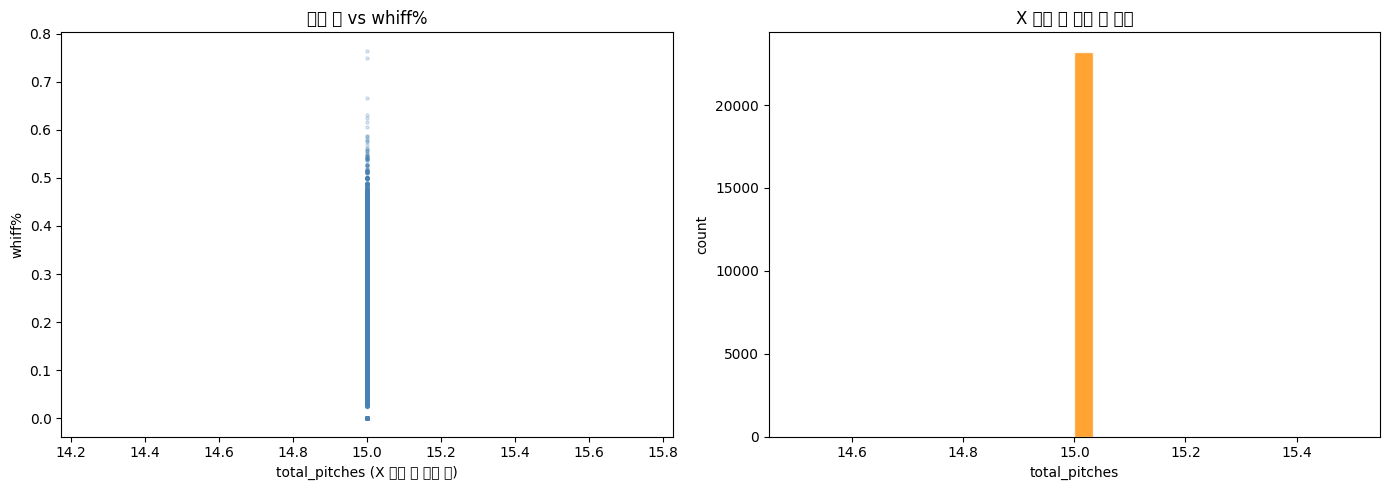

total_pitches 기초 통계:
count    23225.0
mean        15.0
std          0.0
min         15.0
25%         15.0
50%         15.0
75%         15.0
max         15.0
Name: total_pitches, dtype: float64


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# whiff% vs total_pitches 산점도
ax = axes[0]
ax.scatter(df['total_pitches'], y, alpha=0.2, s=5, color='steelblue')
ax.set_xlabel('total_pitches (X 구간 내 투구 수)')
ax.set_ylabel('whiff%')
ax.set_title('투구 수 vs whiff%')

# total_pitches 분포
ax = axes[1]
ax.hist(df['total_pitches'], bins=30, color='darkorange', alpha=0.8, edgecolor='white')
ax.set_xlabel('total_pitches')
ax.set_ylabel('count')
ax.set_title('X 구간 내 투구 수 분포')

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, '03_pitch_vs_whiff.png'), dpi=150, bbox_inches='tight')
plt.show()

print('total_pitches 기초 통계:')
print(df['total_pitches'].describe().round(2))

## 7. 결론 및 Phase 6 방향

위 분석을 바탕으로 이상치 처리 기준을 아래에 정리하세요.

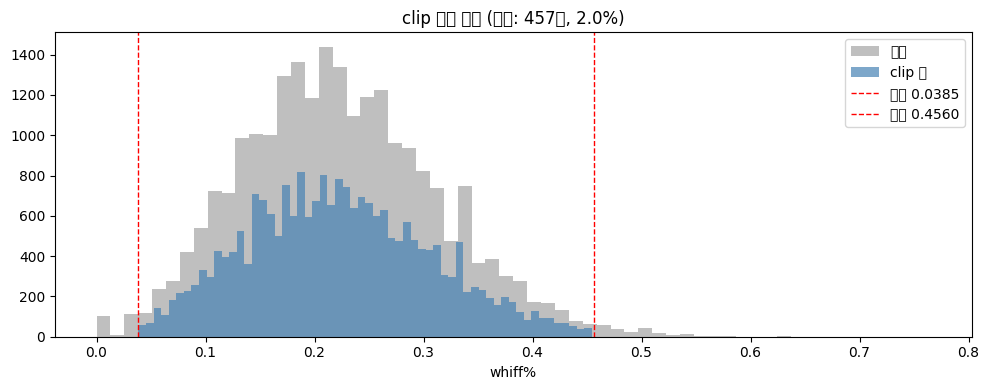

원본 mean=0.2232  std=0.0901
clip mean=0.2224  std=0.0841


In [19]:
# 최종 확인: 선택한 clip 기준 적용 후 분포
# ↓ 아래 값을 분석 결과 보고 수정
CLIP_LO = y.quantile(0.01)
CLIP_HI = y.quantile(0.99)

y_clipped = y[(y >= CLIP_LO) & (y <= CLIP_HI)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y,         bins=60, alpha=0.5, label='원본',  color='gray')
ax.hist(y_clipped, bins=60, alpha=0.7, label='clip 후', color='steelblue')
ax.axvline(CLIP_LO, color='red', linestyle='--', linewidth=1, label=f'하한 {CLIP_LO:.4f}')
ax.axvline(CLIP_HI, color='red', linestyle='--', linewidth=1, label=f'상한 {CLIP_HI:.4f}')
ax.set_xlabel('whiff%')
ax.set_title(f'clip 전후 비교 (제거: {len(y)-len(y_clipped)}개, {(len(y)-len(y_clipped))/len(y):.1%})')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, '04_clip_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'원본 mean={y.mean():.4f}  std={y.std():.4f}')
print(f'clip mean={y_clipped.mean():.4f}  std={y_clipped.std():.4f}')

## 8. 저장 위치 확인

In [20]:
saved = sorted(os.listdir(IMAGE_DIR))
print(f'저장 위치: {IMAGE_DIR}')
print(f'저장된 파일:')
for f in saved:
    print(f'  {f}')

if IN_COLAB:
    print('\n→ Google Drive에서 확인하세요: 내 드라이브 > 투수 컨디션 예측 ML > 5_eda > image')

저장 위치: /content/drive/MyDrive/투수 컨디션 예측 ML/5_eda/image
저장된 파일:
  01_overall_distribution.png
  02_season_distribution.png
  03_pitch_vs_whiff.png
  04_clip_comparison.png

→ Google Drive에서 확인하세요: 내 드라이브 > 투수 컨디션 예측 ML > 5_eda > image
